In [1]:
from pathlib import Path

Path.home()

WindowsPath('C:/Users/cbaez')

In [2]:
from pathlib import Path
import pandas as pd

ruta = Path.home() / "Downloads" / "historico_siniestros_bogota_d.c_-.csv"

df = pd.read_csv(ruta, low_memory=False)

df.head()

,X,Y,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,FECHA_HORA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA
0,-74.090924,4.693807,1,A000640275,4484660,2017/06/12 00:00:00+00,2017,AV AVENIDA BOYACA-CL 79 02,SOLO DANOS,CHOQUE,ENGATIVA,2017/06/12 05:30:00+00,4.693807,-74.090924,10006772.0,221236.0
1,-74.121000,4.603000,2,A001233353,10533499,2020/11/19 00:00:00+00,2020,CL 26 S- KR 50 02,CON HERIDOS,OTRO,PUENTE ARANDA,2020/11/19 02:05:00+00,4.603000,-74.121000,16004560.0,NaN
2,-74.042000,4.682000,4,A001232786,10533629,2020/11/10 00:00:00+00,2020,KR 9 - CL 100 02,SOLO DANOS,CHOQUE,USAQUEN,2020/11/10 13:30:00+00,4.682000,-74.042000,30001107.0,NaN
3,-74.166937,4.587187,7,A000200705,4412699,2015/05/11 00:00:00+00,2015,CL 63A-KR 72 S 02,SOLO DANOS,CHOQUE,CIUDAD BOLIVAR,2015/05/11 10:50:00+00,4.587187,-74.166937,19001483.0,136166.0
4,-74.092901,4.607648,8,A000402862,4447845,2016/06/08 00:00:00+00,2016,KR 27-CL 9 14,SOLO DANOS,CHOQUE,LOS MARTIRES,2016/06/08 21:30:00+00,4.607648,-74.092901,14000548.0,239719.0


In [3]:
print("="*60)
print("DIMENSIONES DEL DATASET")
print("="*60)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

print("\n")
df.info()

DIMENSIONES DEL DATASET
Filas: 199,146
Columnas: 16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199146 entries, 0 to 199145
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   X                     199146 non-null  float64
 1   Y                     199146 non-null  float64
 2   OBJECTID              199146 non-null  int64  
 3   FORMULARIO            199146 non-null  object 
 4   CODIGO_ACCIDENTE      199146 non-null  int64  
 5   FECHA_OCURRENCIA_ACC  199146 non-null  object 
 6   ANO_OCURRENCIA_ACC    199146 non-null  int64  
 7   DIRECCION             199146 non-null  object 
 8   GRAVEDAD              199146 non-null  object 
 9   CLASE_ACC             199146 non-null  object 
 10  LOCALIDAD             199100 non-null  object 
 11  FECHA_HORA_ACC        199146 non-null  object 
 12  LATITUD               199146 non-null  float64
 13  LONGITUD              199146 non-null  float64
 14

In [4]:
calidad = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": round(df.isnull().mean()*100,2),
    "Valores únicos": df.nunique()
})

calidad.sort_values("% Nulos", ascending=False)

,Tipo,Nulos,% Nulos,Valores únicos
PK_CALZADA,float64,37974,19.07,37953
CIV,float64,1701,0.85,38419
LOCALIDAD,object,46,0.02,20
X,float64,0,0.00,109453
Y,float64,0,0.00,110417
OBJECTID,int64,0,0.00,199146
FORMULARIO,object,0,0.00,199146
CODIGO_ACCIDENTE,int64,0,0.00,199146
FECHA_OCURRENCIA_ACC,object,0,0.00,2445
ANO_OCURRENCIA_ACC,int64,0,0.00,7


In [5]:
df["FECHA_HORA_ACC"] = pd.to_datetime(
    df["FECHA_HORA_ACC"],
    utc=True
)

In [6]:
df["FECHA_HORA_ACC"].dtype

datetime64[ns, UTC]

In [7]:
df["anio"] = df["FECHA_HORA_ACC"].dt.year
df["mes"] = df["FECHA_HORA_ACC"].dt.month
df["dia"] = df["FECHA_HORA_ACC"].dt.day
df["hora"] = df["FECHA_HORA_ACC"].dt.hour
df["dia_semana"] = df["FECHA_HORA_ACC"].dt.day_name()

In [8]:
import pandas as pd
from pathlib import Path

In [9]:
ruta1 = Path.home() / "Downloads" / "Precipitación_20260713.csv"
ruta2 = Path.home() / "Downloads" / "Precipitación_20260713 (1).csv"

clima_1 = pd.read_csv(ruta1, low_memory=False)
clima_2 = pd.read_csv(ruta2, low_memory=False)

In [10]:
clima = pd.concat(
    [clima_1, clima_2],
    ignore_index=True
)

print(clima.shape)

(10695810, 12)


In [11]:
clima.head()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,21201200,240,2015 Jan 01 12:00:00 AM,0,ESC LA UNION - FOPAE,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,"4,343","-74,184",Precipitacion,mm
1,21206810,240,2015 Jan 01 12:00:00 AM,0,SAN BENITO - FOPAE,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,"4,55","-74,233",Precipitacion,mm
2,21205791,240,2015 Jan 01 12:00:00 AM,0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,"4,706","-74,151",Precipitacion,mm
3,21202230,240,2015 Jan 01 12:00:00 AM,0,UAN SEDE USME - FOPAE,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,"4,467","-74,117",Precipitacion,mm
4,21201980,240,2015 Jan 01 12:00:00 AM,0,CERRO GUADALUPE - FOPAE,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,"4,567","-74,05",Precipitacion,mm


In [12]:
clima = clima[
    clima["NombreEstacion"] == "APTO EL DORADO - TX GPRS"
].copy()

In [13]:
print(clima.shape)

(344293, 12)


In [14]:
clima["FechaObservacion"] = pd.to_datetime(
    clima["FechaObservacion"]
)

print(clima["FechaObservacion"].min())
print(clima["FechaObservacion"].max())

C:\Users\cbaez\AppData\Local\Temp\ipykernel_91348\2437003378.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clima["FechaObservacion"] = pd.to_datetime(


2015-01-01 00:00:00
2021-12-31 23:50:00


In [15]:
clima["FechaObservacion"] = pd.to_datetime(
    clima["FechaObservacion"],
    format="%Y %b %d %I:%M:%S %p",
    errors="coerce"
)

print("Fechas inválidas:", clima["FechaObservacion"].isna().sum())

Fechas inválidas: 0


In [16]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344293 entries, 2 to 10695809
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   CodigoEstacion     344293 non-null  int64         
 1   CodigoSensor       344293 non-null  int64         
 2   FechaObservacion   344293 non-null  datetime64[ns]
 3   ValorObservado     344293 non-null  object        
 4   NombreEstacion     344293 non-null  object        
 5   Departamento       344293 non-null  object        
 6   Municipio          344293 non-null  object        
 7   ZonaHidrografica   344293 non-null  object        
 8   Latitud            344293 non-null  object        
 9   Longitud           344293 non-null  object        
 10  DescripcionSensor  344293 non-null  object        
 11  UnidadMedida       344293 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 34.1+ MB


In [17]:
clima["Latitud"] = (
    clima["Latitud"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

clima["Longitud"] = (
    clima["Longitud"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [18]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344293 entries, 2 to 10695809
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   CodigoEstacion     344293 non-null  int64         
 1   CodigoSensor       344293 non-null  int64         
 2   FechaObservacion   344293 non-null  datetime64[ns]
 3   ValorObservado     344293 non-null  object        
 4   NombreEstacion     344293 non-null  object        
 5   Departamento       344293 non-null  object        
 6   Municipio          344293 non-null  object        
 7   ZonaHidrografica   344293 non-null  object        
 8   Latitud            344293 non-null  float64       
 9   Longitud           344293 non-null  float64       
 10  DescripcionSensor  344293 non-null  object        
 11  UnidadMedida       344293 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


In [19]:
clima["ValorObservado"].head(20)

2      0
24     0
41     0
53     0
73     0
85     0
105    0
118    0
136    0
152    0
173    0
183    0
207    0
221    0
232    0
259    0
274    0
284    0
303    0
325    0
Name: ValorObservado, dtype: object

In [20]:
clima["ValorObservado"].sample(20)

1759659       0
3191353       0
1774234       0
1676588       0
2777979       0
844662        0
1630081       0
10172824      0
844412        0
876994        0
10684304      0
1698161       0
1726826       0
98425         0
10646769      0
10688220      0
10293923      0
1828726       0
10695256      0
1279886     0,1
Name: ValorObservado, dtype: object

In [21]:
clima["ValorObservado"] = (
    clima["ValorObservado"]
        .astype(str)
        .str.replace(",", ".", regex=False)
)

clima["ValorObservado"] = pd.to_numeric(
    clima["ValorObservado"],
    errors="coerce"
)

In [22]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344293 entries, 2 to 10695809
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   CodigoEstacion     344293 non-null  int64         
 1   CodigoSensor       344293 non-null  int64         
 2   FechaObservacion   344293 non-null  datetime64[ns]
 3   ValorObservado     344293 non-null  float64       
 4   NombreEstacion     344293 non-null  object        
 5   Departamento       344293 non-null  object        
 6   Municipio          344293 non-null  object        
 7   ZonaHidrografica   344293 non-null  object        
 8   Latitud            344293 non-null  float64       
 9   Longitud           344293 non-null  float64       
 10  DescripcionSensor  344293 non-null  object        
 11  UnidadMedida       344293 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 34.1+ MB


In [23]:
clima["ValorObservado"].describe()

count    344293.000000
mean          0.017806
std           0.213448
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          19.030000
Name: ValorObservado, dtype: float64

In [24]:
clima["ValorObservado"].value_counts().head(20)

ValorObservado
0.00    325692
0.01      3817
0.10      2138
0.02      1145
0.20       915
0.03       754
0.04       615
0.30       529
0.05       525
0.06       419
0.07       409
0.40       367
0.09       317
0.08       309
0.50       274
0.11       258
0.12       226
0.13       199
0.60       195
0.14       187
Name: count, dtype: int64

In [25]:
# Diferencia entre mediciones consecutivas
clima = clima.sort_values("FechaObservacion")

clima["delta_minutos"] = (
    clima["FechaObservacion"]
    .diff()
    .dt.total_seconds() / 60
)

clima["delta_minutos"].value_counts().head(10)

delta_minutos
10.0     337453
0.0        5100
70.0       1121
130.0       224
190.0        92
250.0        47
310.0        24
20.0         22
50.0         21
430.0        18
Name: count, dtype: int64

In [26]:
clima[
    clima["delta_minutos"] == 0
].head(20)

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida,delta_minutos
6766731,21205791,240,2019-08-28 00:00:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6767365,21205791,240,2019-08-28 00:00:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6767737,21205791,240,2019-08-28 00:10:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6767750,21205791,240,2019-08-28 00:10:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6769287,21205791,240,2019-08-28 00:20:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6769274,21205791,240,2019-08-28 00:20:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6768269,21205791,240,2019-08-28 00:30:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6768679,21205791,240,2019-08-28 00:30:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6769320,21205791,240,2019-08-28 00:40:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6768097,21205791,240,2019-08-28 00:40:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0


In [27]:
clima[
    clima["delta_minutos"] == 0
][
    [
        "FechaObservacion",
        "ValorObservado",
        "NombreEstacion"
    ]
]

,FechaObservacion,ValorObservado,NombreEstacion
6766731,2019-08-28 00:00:00,0.0,APTO EL DORADO - TX GPRS
6767365,2019-08-28 00:00:00,0.0,APTO EL DORADO - TX GPRS
6767737,2019-08-28 00:10:00,0.0,APTO EL DORADO - TX GPRS
6767750,2019-08-28 00:10:00,0.0,APTO EL DORADO - TX GPRS
6769287,2019-08-28 00:20:00,0.0,APTO EL DORADO - TX GPRS
...,...,...,...
7686309,2019-09-14 23:30:00,0.0,APTO EL DORADO - TX GPRS
7685660,2019-09-14 23:40:00,0.0,APTO EL DORADO - TX GPRS
7685674,2019-09-14 23:40:00,0.0,APTO EL DORADO - TX GPRS
7685161,2019-09-14 23:50:00,0.0,APTO EL DORADO - TX GPRS


In [28]:
clima.duplicated().sum()

2550

In [29]:
clima[
    clima.duplicated(keep=False)
].sort_values("FechaObservacion").head(30)

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida,delta_minutos
6766731,21205791,240,2019-08-28 00:00:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6767365,21205791,240,2019-08-28 00:00:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6767737,21205791,240,2019-08-28 00:10:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6767750,21205791,240,2019-08-28 00:10:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6769287,21205791,240,2019-08-28 00:20:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6769274,21205791,240,2019-08-28 00:20:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6768269,21205791,240,2019-08-28 00:30:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6768679,21205791,240,2019-08-28 00:30:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6768097,21205791,240,2019-08-28 00:40:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0
6769320,21205791,240,2019-08-28 00:40:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0


In [30]:
print("Antes:", len(clima))

clima = clima.drop_duplicates()

print("Después:", len(clima))

Antes: 344293
Después: 341743


In [31]:
clima = clima.sort_values("FechaObservacion")

clima["delta_minutos"] = (
    clima["FechaObservacion"]
    .diff()
    .dt.total_seconds()/60
)

In [32]:
print("Duplicados exactos:", clima.duplicated().sum())

print("\nRegistros por año:")
print(clima["FechaObservacion"].dt.year.value_counts().sort_index())

Duplicados exactos: 0

Registros por año:
FechaObservacion
2015    52156
2016    51930
2017    50773
2018    48375
2019    50658
2020    47102
2021    40749
Name: count, dtype: int64


In [33]:
clima[
    clima["FechaObservacion"] == "2019-08-28 00:00:00"
]

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida,delta_minutos
6766694,21205791,240,2019-08-28,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,10.0
6766731,21205791,240,2019-08-28,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm,0.0


In [34]:
clima["FechaObservacion"].head()

2    2015-01-01 00:00:00
24   2015-01-01 00:10:00
41   2015-01-01 00:20:00
53   2015-01-01 00:30:00
73   2015-01-01 00:40:00
Name: FechaObservacion, dtype: datetime64[ns]

In [35]:
clima["FechaObservacion"].dtype

dtype('<M8[ns]')

In [36]:
clima["FechaObservacion"].iloc[0]

Timestamp('2015-01-01 00:00:00')

In [37]:
clima[
    clima["FechaObservacion"] == "2019-08-28 00:00:00"
].T

,6766694,6766731
CodigoEstacion,21205791,21205791
CodigoSensor,240,240
FechaObservacion,2019-08-28 00:00:00,2019-08-28 00:00:00
ValorObservado,0.0,0.0
NombreEstacion,APTO EL DORADO - TX GPRS,APTO EL DORADO - TX GPRS
Departamento,BOGOTA D.C.,BOGOTA D.C.
Municipio,"BOGOTA, D.C","BOGOTA, D.C"
ZonaHidrografica,ALTO MAGDALENA,ALTO MAGDALENA
Latitud,4.706,4.706
Longitud,-74.151,-74.151


In [38]:
clima_sin_delta = clima.drop(columns=["delta_minutos"])

print(clima_sin_delta.duplicated().sum())

2550


In [39]:
clima_sin_delta[
    clima_sin_delta["FechaObservacion"] == "2019-08-28 00:00:00"
].T

,6766694,6766731
CodigoEstacion,21205791,21205791
CodigoSensor,240,240
FechaObservacion,2019-08-28 00:00:00,2019-08-28 00:00:00
ValorObservado,0.0,0.0
NombreEstacion,APTO EL DORADO - TX GPRS,APTO EL DORADO - TX GPRS
Departamento,BOGOTA D.C.,BOGOTA D.C.
Municipio,"BOGOTA, D.C","BOGOTA, D.C"
ZonaHidrografica,ALTO MAGDALENA,ALTO MAGDALENA
Latitud,4.706,4.706
Longitud,-74.151,-74.151


In [40]:
clima_sin_delta = clima.drop(columns=["delta_minutos"])

print("Duplicados antes:", clima_sin_delta.duplicated().sum())

clima_sin_delta = clima_sin_delta.drop_duplicates()

print("Duplicados después:", clima_sin_delta.duplicated().sum())

Duplicados antes: 2550
Duplicados después: 0


In [41]:
clima_sin_delta[
    clima_sin_delta["FechaObservacion"] == "2019-08-28 00:00:00"
]

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
6766694,21205791,240,2019-08-28,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm


In [42]:
clima_limpio = clima.drop(columns=["delta_minutos"]).drop_duplicates()

print("Registros finales:", len(clima_limpio))

Registros finales: 339193


In [49]:
df["FECHA_HORA_ACC"].dtype

datetime64[ns, UTC]

In [50]:
df["fin_semana"] = (
    df["dia_semana"]
    .isin(["Saturday","Sunday"])
).astype(int)

In [53]:
pip install holidays

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 1.5 MB/s eta 0:00:01
   ------------------- -------------------- 0.8/1.6 MB 1.5 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import holidays

festivos_col = holidays.Colombia()

df["festivo"] = (
    df["FECHA_HORA_ACC"]
    .dt.date
    .isin(festivos_col)
).astype(int)

In [55]:
pip install h3

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import h3
df["h3"] = df.apply(
    lambda row: h3.latlng_to_cell(
        row["LATITUD"],
        row["LONGITUD"],
        8
    ),
    axis=1
)
df[[
    "LATITUD",
    "LONGITUD",
    "h3"
]].head()

,LATITUD,LONGITUD,h3
0,4.693807,-74.090924,8866e428a3fffff
1,4.603000,-74.121000,8866e09001fffff
2,4.682000,-74.042000,8866e42d41fffff
3,4.587187,-74.166937,8866e09111fffff
4,4.607648,-74.092901,8866e0905bfffff


In [ ]:
df.to_parquet("accidentes_h3.parquet")

In [64]:
clima_limpio.columns.tolist()

['CodigoEstacion',
 'CodigoSensor',
 'FechaObservacion',
 'ValorObservado',
 'NombreEstacion',
 'Departamento',
 'Municipio',
 'ZonaHidrografica',
 'Latitud',
 'Longitud',
 'DescripcionSensor',
 'UnidadMedida']

In [65]:
clima_limpio.head()

,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
2,21205791,240,2015-01-01 00:00:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm
24,21205791,240,2015-01-01 00:10:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm
41,21205791,240,2015-01-01 00:20:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm
53,21205791,240,2015-01-01 00:30:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm
73,21205791,240,2015-01-01 00:40:00,0.0,APTO EL DORADO - TX GPRS,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.706,-74.151,Precipitacion,mm


In [66]:
clima_limpio["FechaObservacion"].dtype

dtype('<M8[ns]')

In [67]:
df["FECHA_HORA_ACC"].dtype

datetime64[ns, UTC]

In [68]:
df["FECHA_HORA_ACC"] = (
    df["FECHA_HORA_ACC"]
    .dt.tz_localize(None)
)

In [69]:
print(df["FECHA_HORA_ACC"].dtype)
print(clima_limpio["FechaObservacion"].dtype)

datetime64[ns]
datetime64[ns]


In [70]:
df = df.sort_values("FECHA_HORA_ACC")

clima_limpio = clima_limpio.sort_values(
    "FechaObservacion"
)

In [71]:
clima_limpio = clima_limpio.rename(
    columns={
        "ValorObservado":"precipitacion"
    }
)

In [72]:
clima_limpio["precip_1h"] = (
    clima_limpio["precipitacion"]
    .rolling(6, min_periods=1)
    .sum()
)

In [73]:
clima_limpio["precip_3h"] = (
    clima_limpio["precipitacion"]
    .rolling(18, min_periods=1)
    .sum()
)

In [74]:
dataset = pd.merge_asof(
    df.sort_values("FECHA_HORA_ACC"),
    clima_limpio[
        [
            "FechaObservacion",
            "precipitacion",
            "precip_1h",
            "precip_3h"
        ]
    ].sort_values("FechaObservacion"),
    left_on="FECHA_HORA_ACC",
    right_on="FechaObservacion",
    direction="nearest"
)

In [ ]:
dataset.shape

(199146, 28)

In [76]:
dataset[
    [
        "FECHA_HORA_ACC",
        "precipitacion",
        "precip_1h",
        "precip_3h"
    ]
].head()

,FECHA_HORA_ACC,precipitacion,precip_1h,precip_3h
0,2015-01-01 01:05:00,0.0,0.0,0.0
1,2015-01-01 05:50:00,0.0,0.0,0.0
2,2015-01-01 07:15:00,0.0,0.0,0.0
3,2015-01-01 09:30:00,0.0,0.0,0.0
4,2015-01-01 09:45:00,0.0,0.0,0.0


In [77]:
dataset[[
    "precipitacion",
    "precip_1h",
    "precip_3h"
]].describe()

,precipitacion,precip_1h,precip_3h
count,199146.000000,199146.000000,199146.000000
mean,0.025447,0.140784,0.396475
std,0.260797,1.021576,1.927580
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,15.950000,42.540000,47.790000


In [79]:
dataset[[
    "precipitacion",
    "precip_1h",
    "precip_3h"
]].isna().sum()

precipitacion    0
precip_1h        0
precip_3h        0
dtype: int64

In [80]:
df["LOCALIDAD"].value_counts().head(30)

LOCALIDAD
KENNEDY               23661
ENGATIVA              20928
USAQUEN               19292
SUBA                  18973
FONTIBON              16377
PUENTE ARANDA         14143
CHAPINERO             11696
TEUSAQUILLO           10167
BARRIOS UNIDOS        10094
BOSA                   9417
CIUDAD BOLIVAR         8005
LOS MARTIRES           6250
SANTA FE               5451
TUNJUELITO             5351
SAN CRISTOBAL          5335
RAFAEL URIBE URIBE     5333
USME                   4017
ANTONIO NARINO         3721
CANDELARIA              882
SUMAPAZ                   7
Name: count, dtype: int64

In [83]:
df_engativa = dataset[
    dataset["LOCALIDAD"].str.upper() == "ENGATIVA"
].copy()
print(df_engativa.shape)
df_engativa["LOCALIDAD"].value_counts()

(20928, 28)


LOCALIDAD
ENGATIVA    20928
Name: count, dtype: int64

In [88]:
df_engativa["h3"].nunique()
df_engativa["h3"].value_counts().head()

h3
8866e428a3fffff    1212
8866e0926bfffff    1025
8866e09249fffff     863
8866e428a5fffff     827
8866e4299bfffff     810
Name: count, dtype: int64

In [89]:
df_engativa["fecha"] = (
    df_engativa["FECHA_HORA_ACC"]
    .dt.date
)

print(df_engativa["fecha"].nunique())

2429


In [90]:
print(
    df_engativa["fecha"].min(),
    df_engativa["fecha"].max()
)

2015-01-01 2021-09-08


In [93]:
fechas = pd.date_range(
    start=df_engativa["fecha"].min(),
    end=df_engativa["fecha"].max(),
    freq="D"
)

len(fechas)

2443

In [94]:
h3_unicos = df_engativa["h3"].unique()

len(h3_unicos)

99

In [95]:
import itertools

grid = pd.DataFrame(
    itertools.product(
        h3_unicos,
        fechas
    ),
    columns=["h3","fecha"]
)

grid.shape

(241857, 2)

In [98]:
grid["fecha"] = pd.to_datetime(
    grid["fecha"]
)

accidentes_diarios["fecha"] = pd.to_datetime(
    accidentes_diarios["fecha"]
)

In [100]:
base_modelo = grid.merge(
    accidentes_diarios,
    on=["h3","fecha"],
    how="left"
)

base_modelo["siniestros"] = (
    base_modelo["siniestros"]
    .fillna(0)
)

base_modelo["target"] = (
    base_modelo["siniestros"] > 0
).astype(int)

In [101]:
print(base_modelo.shape)

print(base_modelo["target"].value_counts())

print(base_modelo["target"].value_counts(normalize=True))

(241857, 4)
target
0    223565
1     18292
Name: count, dtype: int64
target
0    0.924369
1    0.075631
Name: proportion, dtype: float64


In [102]:
base_modelo = base_modelo.sort_values(
    ["h3", "fecha"]
)

In [103]:
base_modelo["siniestros_7d"] = (
    base_modelo
    .groupby("h3")["siniestros"]
    .transform(
        lambda x: x.shift(1)
                  .rolling(7, min_periods=1)
                  .sum()
    )
)

In [104]:
base_modelo["siniestros_30d"] = (
    base_modelo
    .groupby("h3")["siniestros"]
    .transform(
        lambda x: x.shift(1)
                  .rolling(30, min_periods=1)
                  .sum()
    )
)

In [105]:
base_modelo[
    [
        "h3",
        "fecha",
        "siniestros",
        "siniestros_7d",
        "siniestros_30d"
    ]
].head(20)

,h3,fecha,siniestros,siniestros_7d,siniestros_30d
197883,8866e0820dfffff,2015-01-01,0.0,NaN,NaN
197884,8866e0820dfffff,2015-01-02,0.0,0.0,0.0
197885,8866e0820dfffff,2015-01-03,0.0,0.0,0.0
197886,8866e0820dfffff,2015-01-04,0.0,0.0,0.0
197887,8866e0820dfffff,2015-01-05,0.0,0.0,0.0
197888,8866e0820dfffff,2015-01-06,0.0,0.0,0.0
197889,8866e0820dfffff,2015-01-07,0.0,0.0,0.0
197890,8866e0820dfffff,2015-01-08,0.0,0.0,0.0
197891,8866e0820dfffff,2015-01-09,0.0,0.0,0.0
197892,8866e0820dfffff,2015-01-10,0.0,0.0,0.0


In [107]:
base_modelo.columns

Index(['h3', 'fecha', 'siniestros', 'target', 'siniestros_7d',
       'siniestros_30d'],
      dtype='object')

In [108]:
base_modelo["dia_semana"] = (
    pd.to_datetime(base_modelo["fecha"])
    .dt.dayofweek
)

base_modelo["mes"] = (
    pd.to_datetime(base_modelo["fecha"])
    .dt.month
)

base_modelo["trimestre"] = (
    pd.to_datetime(base_modelo["fecha"])
    .dt.quarter
)

base_modelo["fin_semana"] = (
    base_modelo["dia_semana"] >= 5
).astype(int)

In [109]:
base_modelo.head()

,h3,fecha,siniestros,target,siniestros_7d,siniestros_30d,dia_semana,mes,trimestre,fin_semana
197883,8866e0820dfffff,2015-01-01,0.0,0,NaN,NaN,3,1,1,0
197884,8866e0820dfffff,2015-01-02,0.0,0,0.0,0.0,4,1,1,0
197885,8866e0820dfffff,2015-01-03,0.0,0,0.0,0.0,5,1,1,1
197886,8866e0820dfffff,2015-01-04,0.0,0,0.0,0.0,6,1,1,1
197887,8866e0820dfffff,2015-01-05,0.0,0,0.0,0.0,0,1,1,0


In [110]:
dataset["fecha"] = (
    dataset["FECHA_HORA_ACC"]
    .dt.date
)

clima_diario = (
    dataset
    .groupby("fecha")
    .agg(
        precipitacion=("precipitacion","mean"),
        precip_1h=("precip_1h","mean"),
        precip_3h=("precip_3h","mean")
    )
    .reset_index()
)

In [111]:
clima_diario["fecha"] = pd.to_datetime(
    clima_diario["fecha"]
)

base_modelo["fecha"] = pd.to_datetime(
    base_modelo["fecha"]
)

In [112]:
base_modelo = base_modelo.merge(
    clima_diario,
    on="fecha",
    how="left"
)

In [113]:
base_modelo.columns

Index(['h3', 'fecha', 'siniestros', 'target', 'siniestros_7d',
       'siniestros_30d', 'dia_semana', 'mes', 'trimestre', 'fin_semana',
       'precipitacion', 'precip_1h', 'precip_3h'],
      dtype='object')

In [114]:
base_modelo.isna().sum()

h3                 0
fecha              0
siniestros         0
target             0
siniestros_7d     99
siniestros_30d    99
dia_semana         0
mes                0
trimestre          0
fin_semana         0
precipitacion      0
precip_1h          0
precip_3h          0
dtype: int64

In [115]:
base_modelo["siniestros_7d"] = (
    base_modelo["siniestros_7d"]
    .fillna(0)
)

base_modelo["siniestros_30d"] = (
    base_modelo["siniestros_30d"]
    .fillna(0)
)

In [116]:
base_modelo.isna().sum()

h3                0
fecha             0
siniestros        0
target            0
siniestros_7d     0
siniestros_30d    0
dia_semana        0
mes               0
trimestre         0
fin_semana        0
precipitacion     0
precip_1h         0
precip_3h         0
dtype: int64

In [117]:
features = [
    "siniestros_7d",
    "siniestros_30d",
    "dia_semana",
    "mes",
    "trimestre",
    "fin_semana",
    "precipitacion",
    "precip_1h",
    "precip_3h"
]

X = base_modelo[features]
y = base_modelo["target"]

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [119]:
print(X_train.shape)
print(X_test.shape)

(193485, 9)
(48372, 9)


In [120]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [121]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("ROC AUC:", roc_auc_score(y_test,y_prob))

Accuracy: 0.702823947738361
Precision: 0.18984777449788737
Recall: 0.896664844177146
F1: 0.31335084786243134
ROC AUC: 0.8470266271368143


In [123]:
import pandas as pd

importancia = pd.DataFrame({
    "Variable":features,
    "Importancia":rf.feature_importances_
})

importancia = importancia.sort_values(
    "Importancia",
    ascending=False
)

print(importancia)

         Variable  Importancia
1  siniestros_30d     0.681094
0   siniestros_7d     0.250328
8       precip_3h     0.016504
7       precip_1h     0.015711
6   precipitacion     0.014427
2      dia_semana     0.009452
3             mes     0.008528
4       trimestre     0.002732
5      fin_semana     0.001225


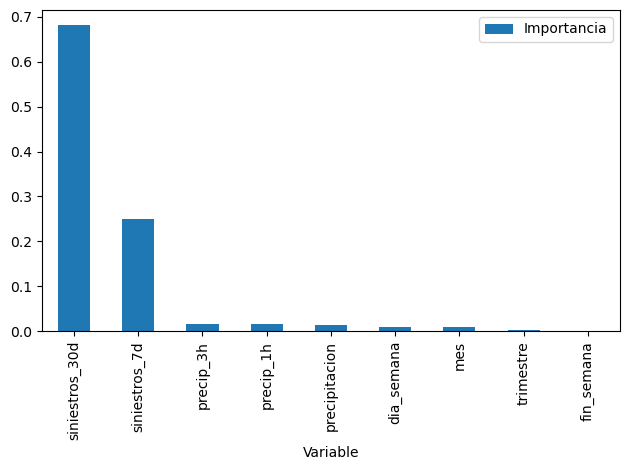

In [124]:
import matplotlib.pyplot as plt

importancia.plot(
    x="Variable",
    y="Importancia",
    kind="bar"
)

plt.tight_layout()
plt.show()

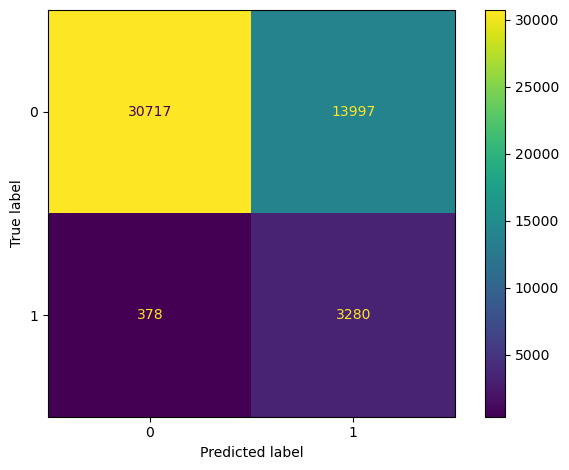

In [125]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.tight_layout()
plt.show()

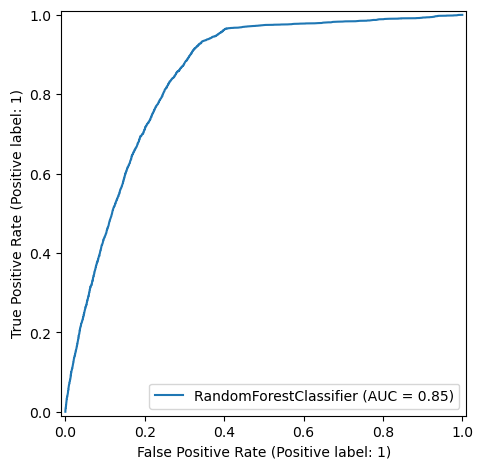

In [126]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.tight_layout()
plt.show()

In [129]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.Collecting xgboost
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 7.2 MB/s eta 0:00:07
   -- ------------------------------------- 2.9/48.9 MB 8.0 MB/s eta 0:00:06
   ---- ----------------------------------- 5.0/48.9 MB 8.9 MB/s eta 0:00:05
   ----- ---------------------------------- 6.8/48.9 MB 9.1 MB/s eta 0:00:05
   ------ --------------------------------- 8.4/48.9 MB 9.0 MB/s eta 0:00:05
   -------- ------------------------------- 10.2/48.9 MB 9.0 MB/s eta 0:00:05
   --------- ------------------------------ 12.1/48.9 MB 8.8 MB/s eta 0:00:05
   ----------- ---------------------------- 13.6/48.9 MB 8.7 MB/s eta 0:00:05
   ------------ --------------------------- 15.2/48.9 MB 8.5 MB/s eta 0:00:04
   -------------- ------------------------- 17.3/48.9 MB 8.7 MB/s eta 0:00:04
   --------------- ------------------------ 19.4/48.9 MB 8.9 MB/s eta 0


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [130]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [132]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test,y_pred_xgb))
print("Precision:", precision_score(y_test,y_pred_xgb))
print("Recall:", recall_score(y_test,y_pred_xgb))
print("F1:", f1_score(y_test,y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test,y_prob_xgb))

Accuracy: 0.9243157198379227
Precision: 0.47368421052631576
Recall: 0.007381082558775287
F1: 0.014535666218034994
ROC AUC: 0.847993093973623


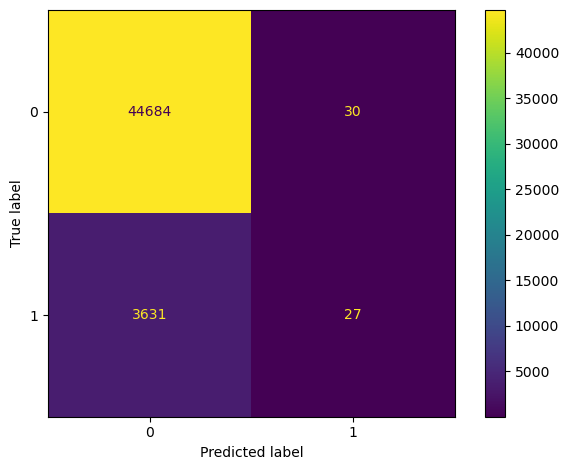

In [133]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.tight_layout()
plt.show()

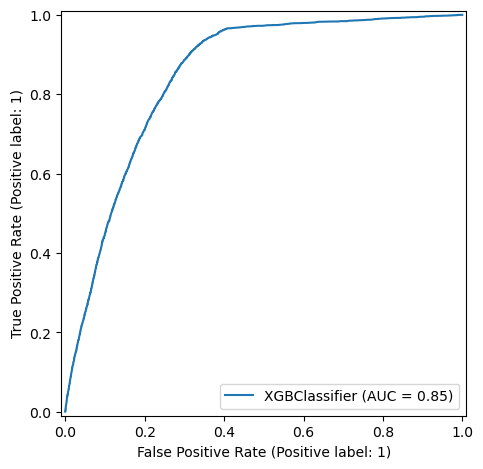

In [134]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.tight_layout()
plt.show()

In [135]:
import pandas as pd

importancia_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb.feature_importances_
})

importancia_xgb = importancia_xgb.sort_values(
    by="Importancia",
    ascending=False
)

print(importancia_xgb)

         Variable  Importancia
1  siniestros_30d     0.721554
0   siniestros_7d     0.102050
5      fin_semana     0.030130
2      dia_semana     0.029265
7       precip_1h     0.025129
8       precip_3h     0.025032
6   precipitacion     0.024250
3             mes     0.021662
4       trimestre     0.020928


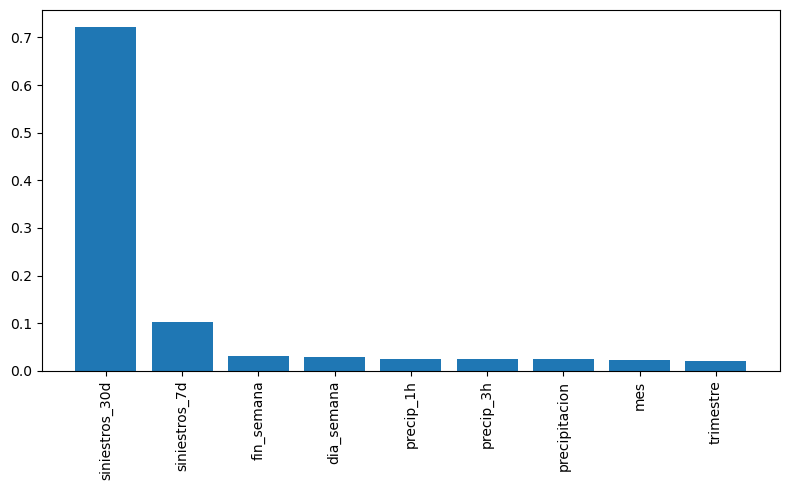

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importancia_xgb["Variable"],
    importancia_xgb["Importancia"]
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [137]:
X.columns

Index(['siniestros_7d', 'siniestros_30d', 'dia_semana', 'mes', 'trimestre',
       'fin_semana', 'precipitacion', 'precip_1h', 'precip_3h'],
      dtype='object')

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [139]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logit.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [140]:
y_pred_logit = logit.predict(X_test_scaled)

y_prob_logit = logit.predict_proba(
    X_test_scaled
)[:,1]

In [141]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test,y_pred_logit))
print("Precision:", precision_score(y_test,y_pred_logit))
print("Recall:", recall_score(y_test,y_pred_logit))
print("F1:", f1_score(y_test,y_pred_logit))
print("ROC AUC:", roc_auc_score(y_test,y_prob_logit))

Accuracy: 0.7934342181427272
Precision: 0.2266056629834254
Recall: 0.7176052487698196
F1: 0.3444429864847133
ROC AUC: 0.8471825295927928


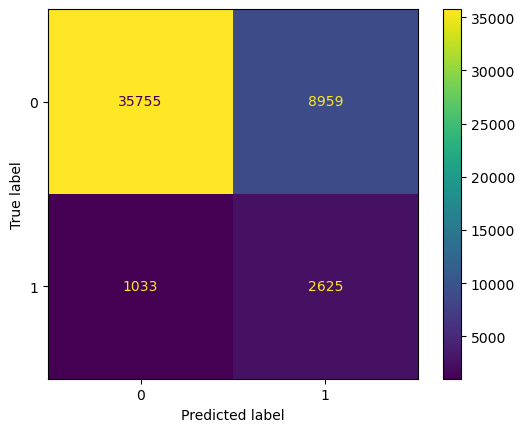

In [142]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    logit,
    X_test_scaled,
    y_test
)

plt.show()

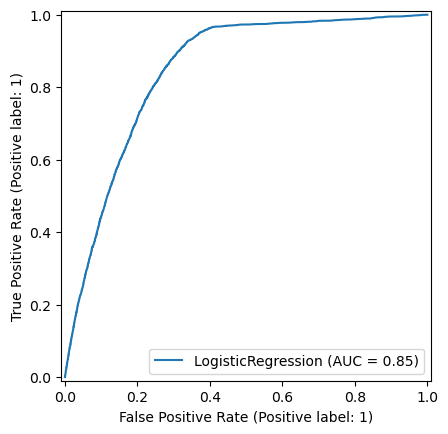

In [143]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    logit,
    X_test_scaled,
    y_test
)

plt.show()

In [144]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": logit.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

print(coeficientes)

         Variable  Coeficiente
1  siniestros_30d     1.219302
4       trimestre     0.074477
0   siniestros_7d     0.037350
8       precip_3h     0.025712
2      dia_semana     0.019866
6   precipitacion     0.013094
7       precip_1h    -0.019480
5      fin_semana    -0.077758
3             mes    -0.101820


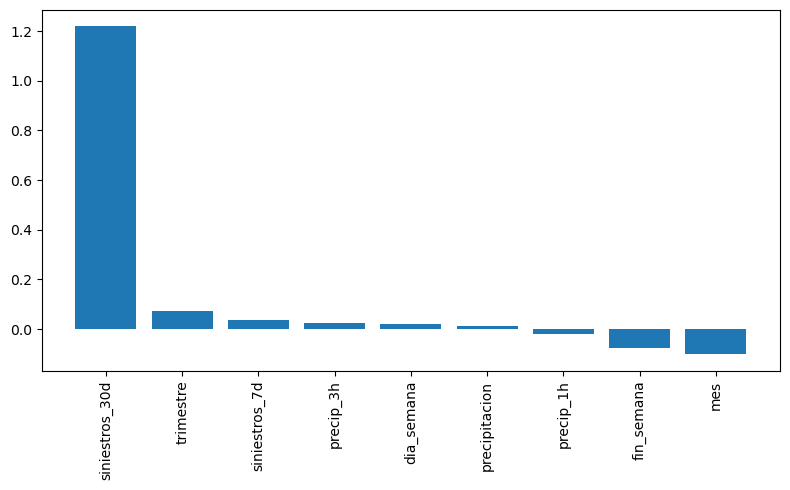

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    coeficientes["Variable"],
    coeficientes["Coeficiente"]
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

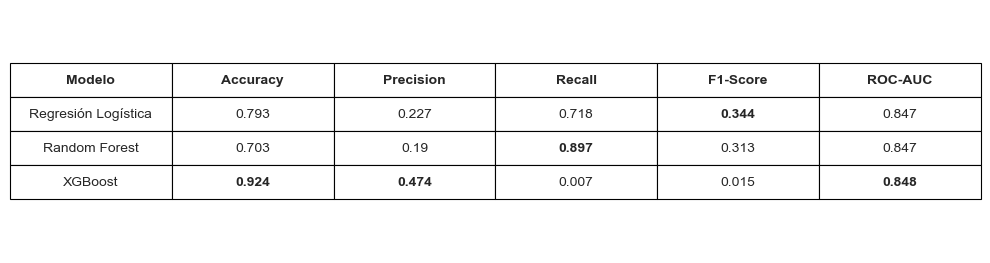

<Figure size 1200x600 with 0 Axes>

In [149]:
import matplotlib.pyplot as plt

# Resultados
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [0.793, 0.703, 0.924],
    "Precision": [0.227, 0.190, 0.474],
    "Recall": [0.718, 0.897, 0.007],
    "F1-Score": [0.344, 0.313, 0.015],
    "ROC-AUC": [0.847, 0.847, 0.848]
})

# Crear figura
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis('off')

# Tabla
tabla = ax.table(
    cellText=comparacion.round(3).values,
    colLabels=comparacion.columns,
    cellLoc='center',
    loc='center'
)

# Tamaño de fuente
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.8)

# Encabezados
for col in range(len(comparacion.columns)):
    tabla[(0, col)].set_text_props(weight='bold')
    tabla[(0, col)].set_facecolor('white')

# Bordes
for key, cell in tabla.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(0.8)

# Resaltar mejores métricas
metricas = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

for j, metrica in enumerate(metricas, start=1):
    fila_max = comparacion[metrica].idxmax() + 1
    tabla[(fila_max, j)].set_text_props(weight='bold')

plt.tight_layout()
plt.savefig(
    "tabla_comparacion_modelos.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.figure(figsize=(12,6))
plt.show()


<Figure size 1200x600 with 0 Axes>

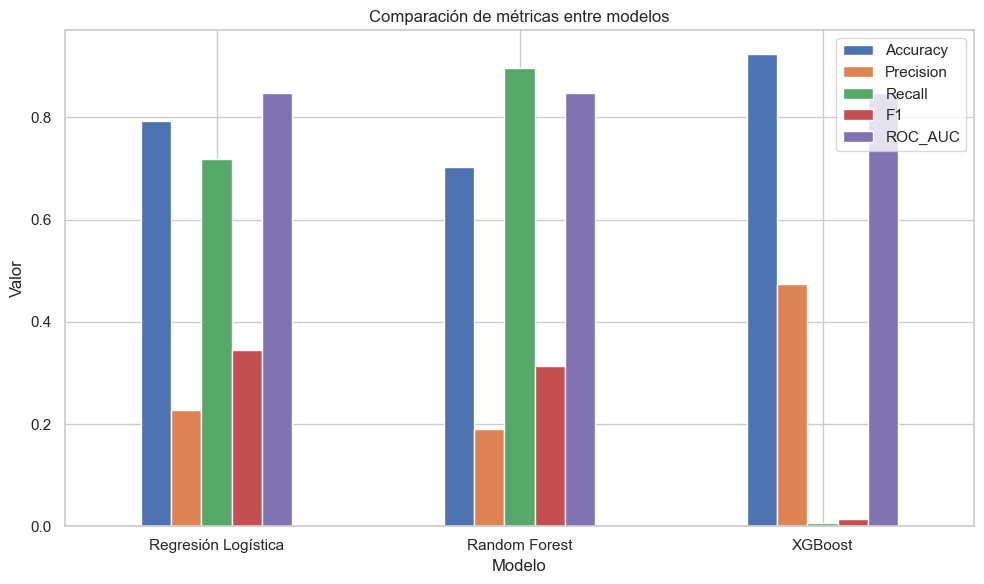

<Figure size 1200x600 with 0 Axes>

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [0.793, 0.703, 0.924],
    "Precision": [0.227, 0.190, 0.474],
    "Recall": [0.718, 0.897, 0.007],
    "F1": [0.344, 0.313, 0.015],
    "ROC_AUC": [0.847, 0.847, 0.848]
})

comparacion.set_index("Modelo").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Valor")
plt.title("Comparación de métricas entre modelos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.figure(figsize=(12,6))